# Plan de la Limace (Massif des Bauges)

## Chargement des librairies

In [1]:
import os
import sys

import matplotlib.pyplot as plt

# Ajout dans la variable PATH du système du chemin où est installée la librairie tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)
# Alias pour tracklib
import tracklib as tkl

# Ajout dans la variable PATH du système du chemin où est installée la librairie footprint2graph
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import matplotlib.pyplot as plt
import os
import time

from footprint2graph import run_iteration
from footprint2graph import read_config

from footprint2graph.util.Outdoorvision import load_raw_tracks_split

## Chargement des paramètres

In [3]:
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('`````````````````````````````````````````````````````````````````````')
print ('             Generate a footprint graph                              ')
print ('                      from hiking trajectories                       ')
print ('                      in the Bauges, summer 2024.                    ')
print ('’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’')
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('')


""" ======================================================================= """
"""     Load parameters                                                     """
"""                                                                         """

config_path = r'/home/md_vandamme/7_LIB/footprint2graph/data/config_plan_de_la_limace.yml'
config = read_config(config_path)


print('Paramètres relevés dans la configuration: ')
print ('Résultats enregistrés dans le répertoire: ', config['output']['RESULT_PATH'])

NBITER = int(config['graph_construction']['NUM_ITERATIONS'])
print ('Number of iterations: ', NBITER)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
             Generate a footprint graph                              
                      from hiking trajectories                       
                      in the Bauges, summer 2024.                    
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Paramètres relevés dans la configuration: 
Résultats enregistrés dans le répertoire:  /home/md_vandamme/4_RESEAU/ZTEMPZ1/
Number of iterations:  2


## Chargement des données

Les données proviennent de la plateforme Outdoorvision. Après avoir été formatées au format CSV, elles sont chargées dans une collection qui servira d'entrée au pipeline.

In [4]:
""" ======================================================================= """
"""     Chargement de la collection de traces                               """
"""                                                                         """

# chemin où sont stockés les traces Outdoorvision:
tracespathsource = r'/home/md_vandamme/5_GPS/OV/BAUGES/walk/'

# Paramètre : Coordonnées de la zone d'étude sur laquelle on construit le réseau
#                           Polygone sous la forme d'un tableau de X et de Y
# traces de la zone 1 (3km x 3km)
X = [950987, 951409, 950696, 949467, 947934, 948545, 950987]
Y = [6513197, 6512091, 6511113, 6510719, 6511949, 6512621, 6513197]

fmt = tkl.TrackFormat({'ext': 'CSV',
                       'srid': 'ENU',
                       'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                       'time_fmt': '2D/2M/4Y 2h:2m:2s',
                       'separator': ';',
                       'header': 0,
                       'cmt': '#',
                       'read_all': True})
collection = load_raw_tracks_split(config['output']['RESULT_PATH'],
                                   tracespathsource, fmt, X, Y)

Loading and split outdoorvision track data...
Reading track data...
     Number files to load:  4145
Starting split ...
     1000 / 4145
     2000 / 4145
     3000 / 4145
     4000 / 4145
     Number of tracks after split: 832


## Lancement du pipeline

In [5]:
for idx in range(0, NBITER):
    iteration_index = int(idx) + 1

    # run pipeline for the ith iteration
    run_iteration(iteration_index, config, collection)

print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('`````````````````````````````````````````````````````````````````````')
print ('                           FIN                                       ')
print ('’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’')
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')

-----------------------------------------------------------------
-----------------------------------------------------------------
              ITERATION  1
-----------------------------------------------------------------
-----------------------------------------------------------------
Starting segmentation and resampling...
Starting segmentation ...
     500 / 832
    Number of tracks after segmentation: 1171
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  1171
    Number of tracks after resampling: 1171
    Number of tracks after resampling: 1171
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.
Starting rasterization and vectorization (iteration 1) 



100% (279 of 279) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (279 of 279) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (406 of 406) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (358 of 358) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (211 of 211) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1204 of 1204) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (3195 of 3195) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (3191 of 3191) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (21702 of 21702) |##################| Elapsed Time: 0:00:00 Time:  0:00:000000


Stage 2 completed: rasterization and vectorization.
Starting topology creation for the network
    /home/md_vandamme/4_RESEAU/ZTEMPZ1/network/tmp_in.csv not exists
    /home/md_vandamme/4_RESEAU/ZTEMPZ1/network/tmp_out.csv not exists


 32% (33 of 102) |#######                | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (102 of 102) |######################| Elapsed Time: 0:00:01 Time:  0:00:010000
100% (102 of 102) |######################| Elapsed Time: 0:00:00 Time:  0:00:00


...

 56% (37 of 66) |#############           | Elapsed Time: 0:00:00 ETA:   0:00:00

100% (66 of 66) |########################| Elapsed Time: 0:00:00 Time:  0:00:000000
100% (66 of 66) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Building [100 x 66] spatial index...
Stage 3 completed: adding topology to the skeleton.
Starting map-matching, aggregation, and conflation of GNSS trajectories.
Stage 4 completed: map-matching, aggregation, and conflation.
Merging the mobility network with the result of iteration 2.


100% (53 of 53) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Building [100 x 74] spatial index...
End building the mobility network.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
                           FIN                                       
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## On affiche le résultat

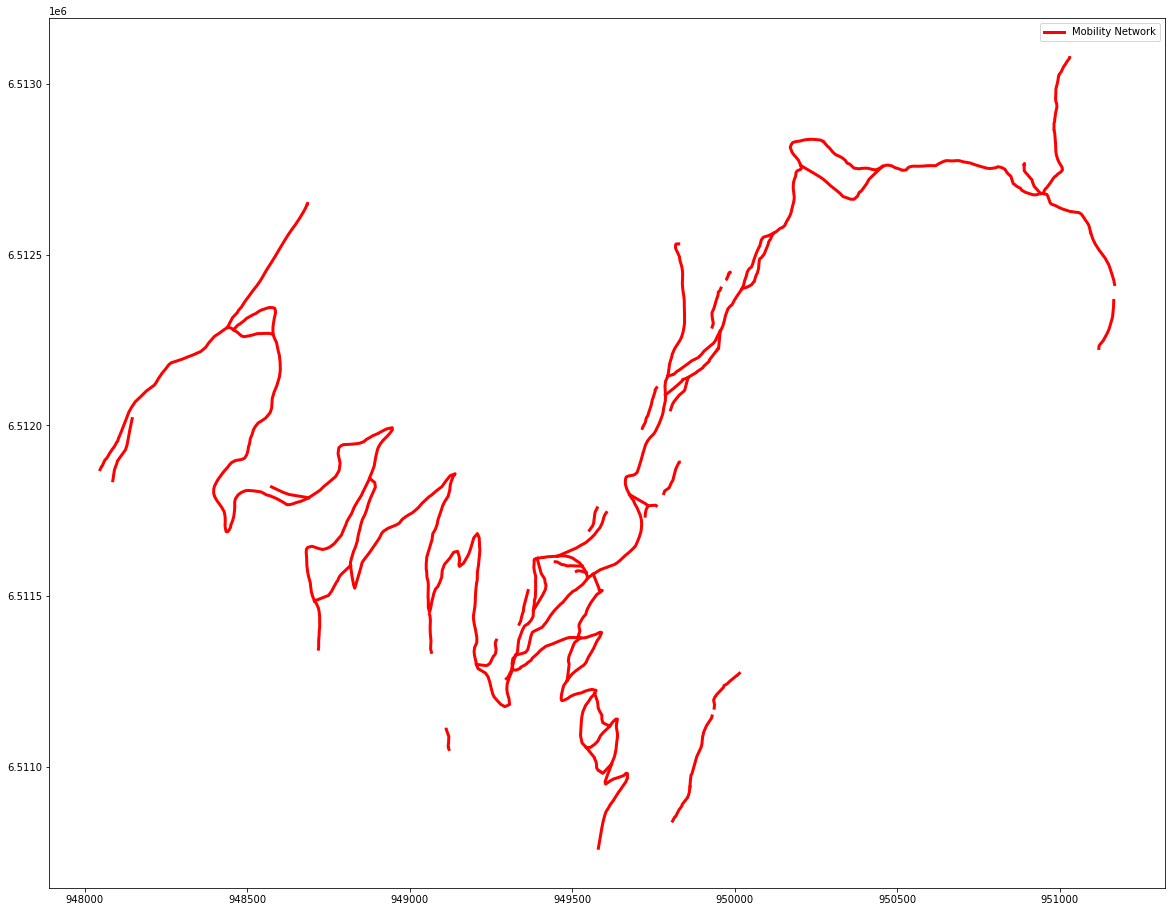

In [6]:
from footprint2graph.util.PlotRes import plotResultatFinal

plotResultatFinal(config['output']['RESULT_PATH'], '2')